# NB05 — The Shift: Confirmatory Analysis
**Signal/Pulse · Market Analysis**

**Hypothesis:** Post-COVID, Japanese consumers have structurally reprioritised
skincare over cosmetics.

**Verdict, after NB04b:** confirmed for makeup, unmeasurable for skincare. The
sources below all measure *attention*; NB04b sets them against METI shipment
statistics and finds the makeup decline corroborated in yen and the skincare
comparison blocked by a break in the official series at January 2022. Read the
sections here as the attention layer, not as demand.

**This notebook tests that hypothesis across independent data sources:**
- Google Trends — anchored スキンケア vs 化粧品 (search demand — §3) and ingredient search (§4)
- Rakuten Ichiba product catalog (commercial supply — §5)

One candidate signal — @cosme review *volume* — is surfaced and excluded as a scraping-coverage artifact (§1–2); the corpus's *language* is analysed in NB06. YouTube corroborates in the dashboard (NB06 §6) but is not re-analysed here.

**Public notebook — brand-agnostic market analysis.**
Company-specific lens analysis in NB05a/b (private, gitignored).

**Canonical tier throughout:** `COALESCE(p.tier_predicted, p.tier_override, c.tier)`
This applies NB02b classifier predictions and NB02 keyword overrides before
falling back to Rakuten's original category assignment.


## 0. Setup

In [1]:
import sys
sys.path.insert(0, "..")

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from src.schema import get_connection
from src.config import PROJECT
from src.viz import PALETTE, fig_ax, tight, annotate_covid, apply_style

apply_style()

# Tier colours — defined once, used across all cells in this notebook
C_SKIN = '#1565C0'  # steel blue
C_COSM = '#D81B60'  # deep rose

conn = get_connection()

for tbl in ['reviews', 'products', 'trends_weekly', 'yt_comments']:
    n = conn.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
    print(f'  {tbl:<20}: {n:>8,} rows')


Font: Hiragino Sans ✓
  reviews             :   46,634 rows
  products            :   46,824 rows
  trends_weekly       :    4,842 rows
  yt_comments         :   74,679 rows


## 1. A Metric We Don't Use — Review Volume by Tier

Review *volume* share is surfaced here and excluded. @cosme is scraped category-by-category, so the tier with more categories collected carries more reviews — tier share of review volume tracks scraping coverage, not the market.

The series shows the artifact directly. Skincare is 100% of 2019 reviews only because no cosmetics categories were scraped for that year; as cosmetics coverage fills in, skincare's share falls 92.7% (2020) → 67.4% (2023) → 69.8% (2025) — the opposite direction to the hypothesis, driven by which categories were collected (7 skincare : 3 cosmetics). Year-over-year corpus composition confounds any cross-period read.

So review volume carries no market claim (METHODOLOGY.md Revision 2). @cosme's contribution is *language*, analysed in NB06. The shift evidence is in §3–§5.

**SQL pattern:** two CTEs — `yearly_tier` aggregates by tier and year, `total_yearly` sums across tiers for the share. The query is correct; the metric is what we exclude.

In [2]:
sql_shift = '''
WITH yearly_tier AS (
    SELECT
        r.review_year,
        COALESCE(p.tier_predicted, p.tier_override, c.tier) AS tier,
        COUNT(*) AS review_count
    FROM reviews r
    JOIN products p   ON r.product_id  = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE r.review_year BETWEEN 2019 AND 2025
      AND COALESCE(p.tier_predicted, p.tier_override, c.tier)
          IN ('skincare', 'cosmetics')
    GROUP BY r.review_year,
             COALESCE(p.tier_predicted, p.tier_override, c.tier)
),
total_yearly AS (
    SELECT
        review_year,
        SUM(review_count) AS total_count
    FROM yearly_tier
    GROUP BY review_year
)
SELECT
    yt.review_year,
    yt.tier,
    yt.review_count,
    ty.total_count,
    ROUND(100.0 * yt.review_count / NULLIF(ty.total_count, 0), 1) AS share_pct
FROM yearly_tier yt
JOIN total_yearly ty ON yt.review_year = ty.review_year
ORDER BY yt.review_year, yt.tier
'''

df_shift = pd.read_sql(sql_shift, conn)
print('Review volume by tier — 2019 to 2025:')
print(df_shift.to_string(index=False))

df_pivot = df_shift.pivot(
    index='review_year', columns='tier',
    values=['review_count', 'share_pct']
)
df_pivot.columns = ['_'.join(col) for col in df_pivot.columns]
print()
print('Pivoted view:')
print(df_pivot.to_string())


Review volume by tier — 2019 to 2025:
 review_year      tier  review_count  total_count  share_pct
        2019  skincare            89           89      100.0
        2020 cosmetics            16          218        7.3
        2020  skincare           202          218       92.7
        2021 cosmetics           111          452       24.6
        2021  skincare           341          452       75.4
        2022 cosmetics           145          928       15.6
        2022  skincare           783          928       84.4
        2023 cosmetics           589         1809       32.6
        2023  skincare          1220         1809       67.4
        2024 cosmetics          1646         4265       38.6
        2024  skincare          2619         4265       61.4
        2025 cosmetics          4252        14080       30.2
        2025  skincare          9828        14080       69.8

Pivoted view:
             review_count_cosmetics  review_count_skincare  share_pct_cosmetics  share_pct_sk

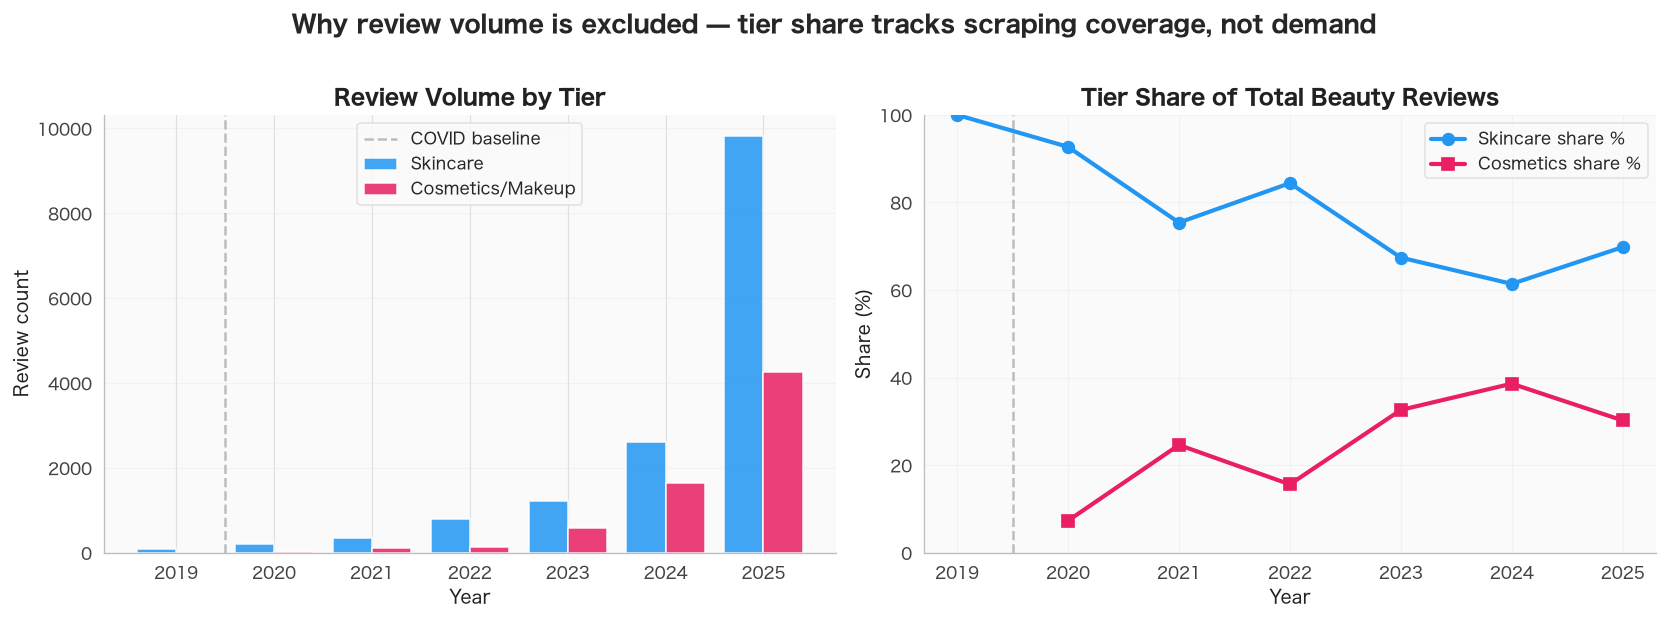

Saved: outputs/nb05_shift_volume.png


In [3]:
# Chart — market share shift
fig, (ax1, ax2) = fig_ax(14, 5, ncols=2)

skin = df_shift[df_shift.tier == 'skincare'].set_index('review_year')
cosm = df_shift[df_shift.tier == 'cosmetics'].set_index('review_year')

# Left: absolute volume
ax1.bar(skin.index - 0.2, skin['review_count'], 0.4,
        label='Skincare', color='#2196F3', alpha=0.85)
ax1.bar(cosm.index + 0.2, cosm['review_count'], 0.4,
        label='Cosmetics/Makeup', color='#E91E63', alpha=0.85)
ax1.axvline(2019.5, color='gray', linestyle='--', alpha=0.5, label='COVID baseline')
ax1.set_title('Review Volume by Tier', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Review count')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Right: share
ax2.plot(skin.index, skin['share_pct'], 'o-',
         color='#2196F3', linewidth=2.5, markersize=7, label='Skincare share %')
ax2.plot(cosm.index, cosm['share_pct'], 's-',
         color='#E91E63', linewidth=2.5, markersize=7, label='Cosmetics share %')
ax2.axvline(2019.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Tier Share of Total Beauty Reviews', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Share (%)')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Why review volume is excluded — tier share tracks scraping coverage, not demand',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/nb05_shift_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/nb05_shift_volume.png')


## 2. The Same Artifact in Year-over-Year Terms

The YoY and pre/post-COVID views show the same coverage effect. Cosmetics review counts grow +594% (2021) and +306% (2023), skincare +275% (2025) — corpus expansion as categories and snapshots accumulate, not demand. The "pre-COVID baseline" is two years of skincare-only coverage (127 reviews total), so the pre/post step marks when collection began, not a market inflection.

The COVID inflection is tested on search demand in §3, where スキンケア and 化粧品 sit on a comparable anchored scale.

**SQL pattern:** `CASE` to classify pre/post-COVID years; `LAG()` for the year-over-year step.

In [4]:
sql_covid = '''
WITH yearly AS (
    SELECT
        r.review_year,
        COALESCE(p.tier_predicted, p.tier_override, c.tier) AS tier,
        COUNT(*) AS review_count
    FROM reviews r
    JOIN products p   ON r.product_id  = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE r.review_year BETWEEN 2018 AND 2025
      AND COALESCE(p.tier_predicted, p.tier_override, c.tier)
          IN ('skincare', 'cosmetics')
    GROUP BY r.review_year,
             COALESCE(p.tier_predicted, p.tier_override, c.tier)
),
with_lag AS (
    SELECT
        *,
        LAG(review_count) OVER (PARTITION BY tier ORDER BY review_year) AS prev_count,
        CASE
            WHEN review_year <= 2019 THEN 'pre_covid'
            ELSE 'post_covid'
        END AS period
    FROM yearly
)
SELECT
    tier,
    review_year,
    review_count,
    prev_count,
    ROUND(100.0 * (review_count - prev_count) / NULLIF(prev_count, 0), 1) AS yoy_pct,
    period
FROM with_lag
ORDER BY tier, review_year
'''

df_covid = pd.read_sql(sql_covid, conn)
print('YoY change and COVID period classification:')
print(df_covid.to_string(index=False))

sql_baseline = '''
SELECT
    tier,
    CASE WHEN review_year <= 2019
         THEN 'Pre-COVID (≤2019)'
         ELSE 'Post-COVID (2020+)'
    END AS period,
    COUNT(DISTINCT review_year)    AS years,
    ROUND(AVG(review_count), 0)    AS avg_annual_reviews,
    SUM(review_count)              AS total_reviews
FROM (
    SELECT
        r.review_year,
        COALESCE(p.tier_predicted, p.tier_override, c.tier) AS tier,
        COUNT(*) AS review_count
    FROM reviews r
    JOIN products p   ON r.product_id  = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE r.review_year BETWEEN 2018 AND 2025
      AND COALESCE(p.tier_predicted, p.tier_override, c.tier)
          IN ('skincare', 'cosmetics')
    GROUP BY r.review_year,
             COALESCE(p.tier_predicted, p.tier_override, c.tier)
)
GROUP BY tier, period
ORDER BY tier, period
'''
df_baseline = pd.read_sql(sql_baseline, conn)
print()
print('Pre vs post-COVID averages:')
print(df_baseline.to_string(index=False))


YoY change and COVID period classification:
     tier  review_year  review_count  prev_count  yoy_pct     period
cosmetics         2020            16         NaN      NaN post_covid
cosmetics         2021           111        16.0    593.8 post_covid
cosmetics         2022           145       111.0     30.6 post_covid
cosmetics         2023           589       145.0    306.2 post_covid
cosmetics         2024          1646       589.0    179.5 post_covid
cosmetics         2025          4252      1646.0    158.3 post_covid
 skincare         2018            38         NaN      NaN  pre_covid
 skincare         2019            89        38.0    134.2  pre_covid
 skincare         2020           202        89.0    127.0 post_covid
 skincare         2021           341       202.0     68.8 post_covid
 skincare         2022           783       341.0    129.6 post_covid
 skincare         2023          1220       783.0     55.8 post_covid
 skincare         2024          2619      1220.0    114.7 p

## 3. Search Demand — スキンケア vs 化粧品 (Anchored, Block B)

Google Trends ships two query blocks here. **Block A** pulls each term in a
*separate* call, so every term is normalised to its own peak — the levels of
different terms are not comparable. Averaging an unequal skincare basket (12
terms, inflated by ingredient names) against a cosmetics basket (4 terms) and
comparing the two produced a spurious "2023 crossover" in earlier versions.
**Block B** anchors every term against a shared reference (基礎化粧品), placing
スキンケア and 化粧品 on one comparable 0–100 scale.

On the anchored block_B there is **no crossover**: 化粧品 search demand falls
~a third (2019→2025) while スキンケア holds roughly flat. The gap narrows, but
化粧品 still out-searches スキンケア in every year.

Two limits on how far this comparison can be pushed. First, **「化粧品」 is the
Japanese umbrella term** — it includes skincare — so part of the narrowing is
consumers naming the specific product type more and the umbrella less, rather
than any shift between categories. The product-word comparisons (ファンデーション,
口紅, 美容液) carry no such confound and are the ones NB04b can check against
official statistics. Second, this measures **attention**, and the behavioural
check in NB04b confirms the makeup side while finding the skincare side
untestable across a break in the source series at January 2022.

Block A stays valid for tracking a *single* term's growth over time (the
ingredient surge in §4), where no cross-term level comparison is made.

**SQL pattern:** filter `term_group='block_B'`, average weekly `interest` by year.


In [5]:
# Anchored block_B — the only block where スキンケア and 化粧品 share a
# comparable 0–100 scale (both normalised against the 基礎化粧品 anchor).
# Block A normalises each term to its OWN peak, so cross-term level reads
# there are invalid — origin of the retired "2023 crossover".
sql_trends_class = '''
    SELECT
        CAST(SUBSTR(tw.week_start, 1, 4) AS INTEGER) AS trend_year,
        CASE WHEN tw.term = 'スキンケア' THEN 'skincare_signal'
             WHEN tw.term = '化粧品'      THEN 'cosmetics_signal' END AS signal_class,
        ROUND(AVG(tw.interest), 1) AS avg_interest
    FROM trends_weekly tw
    WHERE tw.term_group = 'block_B'
      AND tw.term IN ('スキンケア', '化粧品')
    GROUP BY trend_year, signal_class
    ORDER BY trend_year, signal_class
'''
df_trends = pd.read_sql(sql_trends_class, conn)
print('Anchored search interest — スキンケア vs 化粧品 (block_B):')
print(df_trends.pivot(index='trend_year', columns='signal_class',
                      values='avg_interest').to_string())

Anchored search interest — スキンケア vs 化粧品 (block_B):
signal_class  cosmetics_signal  skincare_signal
trend_year                                     
2019                      85.6             26.9
2020                      77.4             33.4
2021                      69.5             31.9
2022                      67.3             32.7
2023                      66.4             32.8
2024                      59.7             31.2
2025                      57.8             30.6
2026                      55.8             32.0


Saved → ../outputs/nb05_trends_shift.png


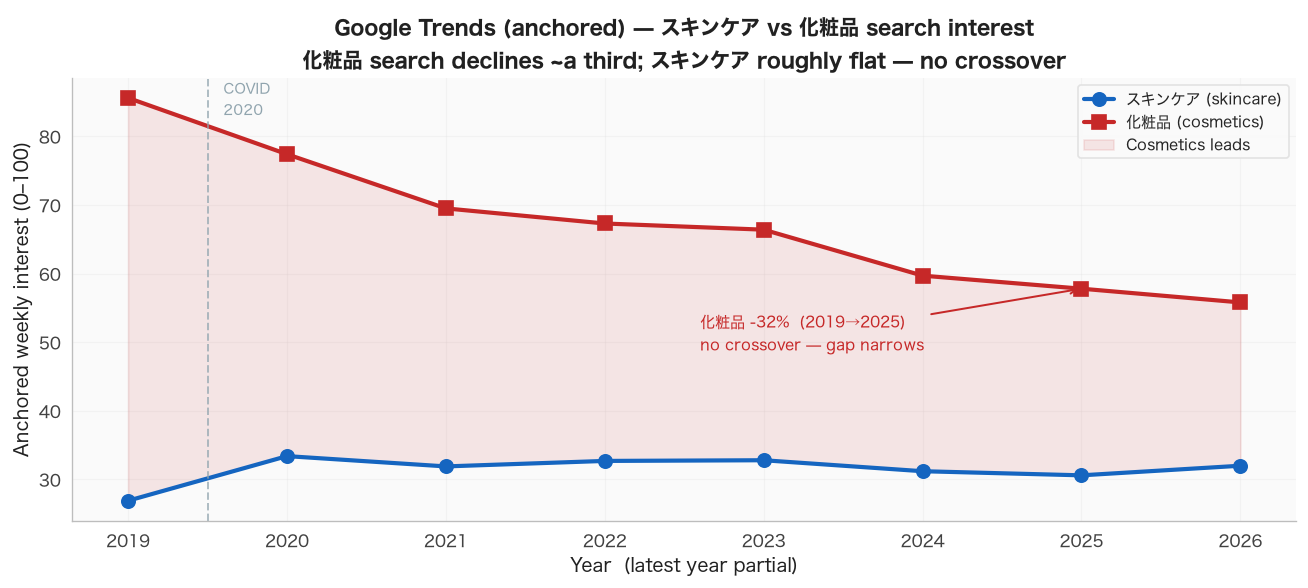

Saved: outputs/nb05_trends_shift.png


In [6]:
# Chart — anchored スキンケア vs 化粧品 search demand (no crossover)
import datetime as _dt
fig, ax = fig_ax(11, 5)

skin_t = df_trends[df_trends.signal_class == 'skincare_signal'].set_index('trend_year')['avg_interest']
cosm_t = df_trends[df_trends.signal_class == 'cosmetics_signal'].set_index('trend_year')['avg_interest']

ax.plot(skin_t.index, skin_t.values, 'o-', color=PALETTE['skincare'],
        linewidth=2.5, markersize=8, label='スキンケア (skincare)')
ax.plot(cosm_t.index, cosm_t.values, 's-', color=PALETTE['cosmetics'],
        linewidth=2.5, markersize=8, label='化粧品 (cosmetics)')

# Gap shading — 化粧品 leads throughout (no crossover)
common = sorted(set(skin_t.index) & set(cosm_t.index))
ax.fill_between(common, [skin_t[y] for y in common], [cosm_t[y] for y in common],
                alpha=0.10, color=PALETTE['cosmetics'], label='Cosmetics leads')

ax.axvline(2019.5, color='#90A4AE', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(2019.6, ax.get_ylim()[1], 'COVID\n2020',
        fontsize=8.5, color='#90A4AE', va='top')

# Decline over FULL calendar years (drop a partial current year)
first = int(cosm_t.index.min())
last  = int(cosm_t.index.max())
partial = last == _dt.date.today().year
if partial:
    last -= 1
decline = 100 * (cosm_t[last] - cosm_t[first]) / cosm_t[first]
ax.annotate(f'化粧品 {decline:+.0f}%  ({first}→{last})\nno crossover — gap narrows',
            xy=(last, cosm_t[last]), xytext=(last - 2.4, cosm_t[last] - 9),
            fontsize=9, color=PALETTE['cosmetics'],
            arrowprops=dict(arrowstyle='->', color=PALETTE['cosmetics'], lw=1.2))

xlabel = 'Year' + ('  (latest year partial)' if partial else '')
ax.set_title('Google Trends (anchored) — スキンケア vs 化粧品 search interest\n'
             '化粧品 search declines ~a third; スキンケア roughly flat — no crossover',
             fontsize=12, fontweight='bold')
ax.set_xlabel(xlabel, fontsize=11)
ax.set_ylabel('Anchored weekly interest (0–100)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
tight(fig, '../outputs/nb05_trends_shift.png')
plt.show()
print('Saved: outputs/nb05_trends_shift.png')


## 4. The Ingredient Intelligence Signal

A sub-hypothesis: post-COVID Japanese consumers aren't just searching more skincare —
they're searching it *differently*. Ingredient-specific search terms
(レチノール, ナイアシンアミド, セラミド) rise post-COVID, with consumers looking up
actives by name.

**SQL pattern:** Individual term time-series from Block A, with `AVG() OVER`
rolling 8-week smoothing to show the trend signal cleanly.


In [7]:
ingredient_terms = ['レチノール', 'ナイアシンアミド', 'セラミド',
                    'ヒアルロン酸', 'ビタミンC 美容', 'アゼライン酸', 'エクソソーム']

sql_ingredients = f'''
SELECT
    term,
    week_start,
    interest,
    AVG(interest) OVER (
        PARTITION BY term
        ORDER BY week_start
        ROWS BETWEEN 7 PRECEDING AND CURRENT ROW
    ) AS rolling_8wk
FROM trends_weekly
WHERE term_group = 'block_A'
  AND term IN ({",".join(f"'{t}'" for t in ingredient_terms)})
  AND week_start >= '2019-01-01'
ORDER BY term, week_start
'''

df_ing = pd.read_sql(sql_ingredients, conn)
print(f'Ingredient trend rows: {len(df_ing)}')
print(f'Terms found: {df_ing.term.unique().tolist()}')

# Summary stats per term
# Windows: first full calendar year vs the last, dropping any partial current
# year — the same anchors the headline 化粧品 decline uses, so the document rests
# on one window rather than two. The earlier <2020 vs >=2020 split put the COVID
# years themselves into "post"; a <=2020 baseline folds the first COVID year into
# "pre". Both distort a structural read, in opposite directions.
_yr = pd.read_sql(f'''
    SELECT CAST(strftime('%Y', week_start) AS INT) AS y,
           COUNT(DISTINCT week_start) AS n
    FROM trends_weekly
    WHERE term_group = 'block_A'
      AND term IN ({",".join(f"'{t}'" for t in ingredient_terms)})
    GROUP BY y ORDER BY y
''', conn)
_full = _yr[_yr.n >= 12].y.tolist()
Y0, Y1 = int(_full[0]), int(_full[-1])
print(f'Ingredient windows: {Y0} vs {Y1} (full calendar years)')

sql_ing_summary = f'''
SELECT
    term,
    ROUND(AVG(CASE WHEN week_start >= '{Y0}-01-01'
                    AND week_start <  '{Y0 + 1}-01-01' THEN interest END), 1) AS avg_pre_covid,
    ROUND(AVG(CASE WHEN week_start >= '{Y1}-01-01'
                    AND week_start <  '{Y1 + 1}-01-01' THEN interest END), 1) AS avg_post_covid,
    ROUND(MAX(interest), 0) AS peak_interest,
    MAX(week_start) AS peak_week
FROM trends_weekly
WHERE term_group = 'block_A'
  AND term IN ({",".join(f"'{t}'" for t in ingredient_terms)})
GROUP BY term
ORDER BY avg_post_covid DESC
'''
df_ing_sum = pd.read_sql(sql_ing_summary, conn)
print()
print('Ingredient interest: pre vs post COVID:')
print(df_ing_sum.to_string(index=False))


Ingredient trend rows: 630
Terms found: ['アゼライン酸', 'エクソソーム', 'セラミド', 'ナイアシンアミド', 'ヒアルロン酸', 'ビタミンC 美容', 'レチノール']
Ingredient windows: 2019 vs 2025 (full calendar years)

Ingredient interest: pre vs post COVID:
    term  avg_pre_covid  avg_post_covid  peak_interest  peak_week
  ヒアルロン酸           52.5            89.8          100.0 2026-06-01
ナイアシンアミド            5.2            80.6          100.0 2026-06-01
  アゼライン酸            0.8            76.3          100.0 2026-06-01
   レチノール           10.3            68.8          100.0 2026-06-01
ビタミンC 美容           23.7            65.9          100.0 2026-06-01
    セラミド           54.2            52.5          100.0 2026-06-01
  エクソソーム            4.8            35.9          100.0 2026-06-01


Saved → ../outputs/nb05_ingredient_stacked.png


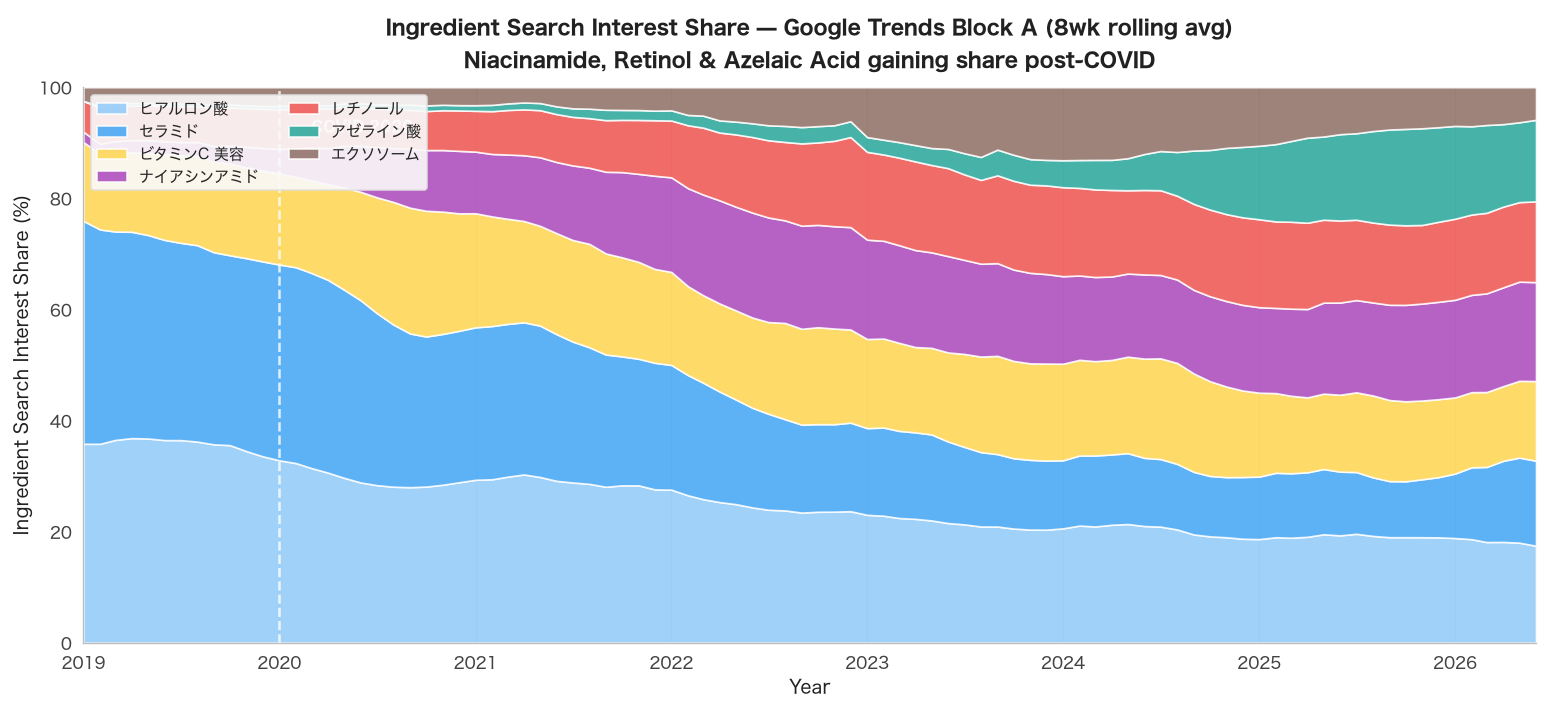

Saved: outputs/nb05_ingredient_stacked.png


In [8]:
# Chart — Stacked area: ingredient search interest composition 2019-2026
# Each ingredient shown as share of total ingredient search interest.
# Reveals not just "all rising" but WHICH ingredients gained share.
# Composition shift: retinol, niacinamide and azelaic acid gain share
# against the ceramide/HA baseline.

if len(df_ing) > 0:
    # Pivot to wide format: rows = week, cols = ingredient
    df_wide = df_ing.pivot_table(
        index='week_start', columns='term', values='rolling_8wk', aggfunc='mean'
    ).fillna(0)
    df_wide.index = pd.to_datetime(df_wide.index)
    df_wide = df_wide.sort_index()

    # Normalise each row to sum to 100 — shows composition share
    row_sums = df_wide.sum(axis=1).replace(0, 1)
    df_pct = df_wide.div(row_sums, axis=0) * 100

    # Colour palette — sequential blues/purples for ingredient family
    ingredient_colors = {
        'ヒアルロン酸':    '#90CAF9',  # light blue — baseline moisturiser
        'セラミド':        '#42A5F5',  # mid blue — barrier repair
        'ビタミンC 美容':  '#FFD54F',  # amber — brightening
        'ナイアシンアミド': '#AB47BC',  # purple — multipurpose
        'レチノール':      '#EF5350',  # red — actives
        'レチナール':      '#FF7043',  # deep orange — actives
        'アゼライン酸':    '#26A69A',  # teal — emerging
        'エクソソーム':    '#8D6E63',  # brown — cutting edge
    }
    cols_ordered = [c for c in [  # DB term keys — must match ingredient_colors
        'ヒアルロン酸','セラミド','ビタミンC 美容',
        'ナイアシンアミド','レチノール','レチナール',
        'アゼライン酸','エクソソーム'
    ] if c in df_pct.columns]

    fig, ax = fig_ax(13, 6)
    ax.stackplot(df_pct.index,
                 [df_pct[c] for c in cols_ordered],
                 labels=cols_ordered,
                 colors=[ingredient_colors.get(c, '#B0BEC5') for c in cols_ordered],
                 alpha=0.85)

    ax.axvline(pd.Timestamp('2020-01-01'), color='white',
               linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(pd.Timestamp('2020-03-01'), 92, 'COVID 2020',
            fontsize=8.5, color='white', fontweight='bold')

    ax.set_xlim(df_pct.index.min(), df_pct.index.max())
    ax.set_ylim(0, 100)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Ingredient Search Interest Share (%)', fontsize=11)
    ax.set_title('Ingredient Search Interest Share — Google Trends Block A (8wk rolling avg)\n'
             'Niacinamide, Retinol & Azelaic Acid gaining share post-COVID',
                 fontsize=12, fontweight='bold', pad=12)
    ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.9)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(axis='y', alpha=0.2, color='white')

    tight(fig, '../outputs/nb05_ingredient_stacked.png')
    plt.show()
    print('Saved: outputs/nb05_ingredient_stacked.png')


## 5. Commercial Validation — Rakuten Product Catalog

Rakuten represents the commercial supply side. If skincare is structurally
dominant, the product catalog should reflect it: more SKUs, higher review
volumes, competitive pricing.

**SQL pattern:** Aggregate product stats by tier from Rakuten snapshot.
`NTILE(4)` to segment price points. Cross-validates the demand-side signal.


In [9]:
sql_rakuten = '''
SELECT
    COALESCE(p.tier_predicted, p.tier_override, c.tier) AS tier,
    c.normalized_name           AS category,
    COUNT(*)                    AS product_count,
    ROUND(AVG(p.price_jpy), 0) AS avg_price_jpy,
    ROUND(MIN(p.price_jpy), 0) AS min_price_jpy,
    ROUND(MAX(p.price_jpy), 0) AS max_price_jpy,
    ROUND(AVG(p.review_count), 1) AS avg_review_count,
    ROUND(AVG(p.review_avg), 2)   AS avg_rating,
    SUM(p.review_count)           AS total_consumer_reviews
FROM products p
JOIN categories c ON p.category_id = c.category_id
WHERE p.source_id = 1
  AND COALESCE(p.tier_predicted, p.tier_override, c.tier) IN ('skincare', 'cosmetics')
  AND p.review_count IS NOT NULL
  AND p.price_jpy IS NOT NULL
  AND p.price_jpy > 0
GROUP BY COALESCE(p.tier_predicted, p.tier_override, c.tier)
ORDER BY COALESCE(p.tier_predicted, p.tier_override, c.tier), product_count DESC
'''

df_rak = pd.read_sql(sql_rakuten, conn)
print('Rakuten product catalog by category:')
print(df_rak.to_string(index=False))

# Tier-level summary
sql_rak_tier = '''
SELECT
    COALESCE(p.tier_predicted, p.tier_override, c.tier) AS tier,
    COUNT(*)                       AS product_count,
    ROUND(AVG(p.price_jpy), 0)     AS avg_price_jpy,
    ROUND(AVG(p.review_count), 1)  AS avg_reviews_per_product,
    ROUND(AVG(p.review_avg), 2)    AS avg_rating,
    SUM(p.review_count)            AS total_consumer_reviews
FROM products p
JOIN categories c ON p.category_id = c.category_id
WHERE p.source_id = 1
  AND COALESCE(p.tier_predicted, p.tier_override, c.tier) IN ('skincare', 'cosmetics')
  AND p.review_count IS NOT NULL
  AND p.price_jpy IS NOT NULL
  AND p.price_jpy > 0
GROUP BY COALESCE(p.tier_predicted, p.tier_override, c.tier)
ORDER BY product_count DESC
'''
df_rak_tier = pd.read_sql(sql_rak_tier, conn)
print()
print('Tier summary:')
print(df_rak_tier.to_string(index=False))


Rakuten product catalog by category:
     tier         category  product_count  avg_price_jpy  min_price_jpy  max_price_jpy  avg_review_count  avg_rating  total_consumer_reviews
cosmetics korean_cosmetics           9758         3279.0            1.0       374000.0             107.8        3.59                 1051646
 skincare       all_in_one          36032         4985.0            1.0       334206.0             120.2        3.75                 4332284

Tier summary:
     tier  product_count  avg_price_jpy  avg_reviews_per_product  avg_rating  total_consumer_reviews
 skincare          36032         4985.0                    120.2        3.75                 4332284
cosmetics           9758         3279.0                    107.8        3.59                 1051646


Saved → ../outputs/nb05_rakuten_table.png


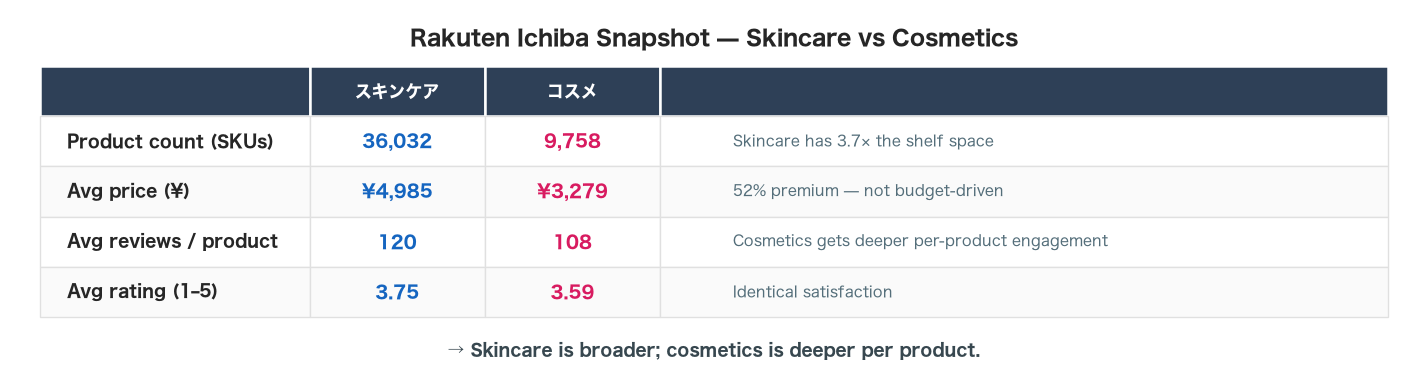

Saved: outputs/nb05_rakuten_table.png


In [10]:
# Rakuten Ichiba — Skincare vs Cosmetics snapshot
# Four metrics, two categories — shown as a table.

df_div = df_rak.groupby('tier').agg(
    product_count    = ('product_count',    'sum'),
    avg_price_jpy    = ('avg_price_jpy',    'mean'),
    avg_review_count = ('avg_review_count', 'mean'),
    avg_rating       = ('avg_rating',       'mean'),
).round(2)

skin = df_div.loc['skincare']  if 'skincare'  in df_div.index else None
cosm = df_div.loc['cosmetics'] if 'cosmetics' in df_div.index else None

rows = [
    ('Product count (SKUs)',
     f'{skin["product_count"]:,.0f}',
     f'{cosm["product_count"]:,.0f}',
     f'Skincare has {skin["product_count"]/cosm["product_count"]:.1f}× the shelf space'),
    ('Avg price (¥)',
     f'¥{skin["avg_price_jpy"]:,.0f}',
     f'¥{cosm["avg_price_jpy"]:,.0f}',
     f'{(skin["avg_price_jpy"]/cosm["avg_price_jpy"]-1)*100:.0f}% premium — not budget-driven'),
    ('Avg reviews / product',
     f'{skin["avg_review_count"]:.0f}',
     f'{cosm["avg_review_count"]:.0f}',
     'Cosmetics gets deeper per-product engagement'),
    ('Avg rating (1–5)',
     f'{skin["avg_rating"]:.2f}',
     f'{cosm["avg_rating"]:.2f}',
     'Identical satisfaction'),
]

df_table = pd.DataFrame(rows, columns=['Metric', 'Skincare', 'Cosmetics', 'Read'])

# ── Render as matplotlib table ────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 3.2), facecolor='white')
ax.axis('off')

# Title
ax.text(0.5, 0.95, 'Rakuten Ichiba Snapshot — Skincare vs Cosmetics',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=13, fontweight='bold')

col_labels = ['', 'スキンケア', 'コスメ', '']
cell_text  = [[r[0], r[1], r[2], r[3]] for r in rows]

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='center',
    colLoc='center',
    loc='center',
    bbox=[0.02, 0.0, 0.96, 0.82],
)

table.auto_set_font_size(False)
table.set_fontsize(10)

# Style header row
for j in range(4):
    cell = table[0, j]
    cell.set_facecolor('#2E4057')
    cell.set_text_props(color='white', fontweight='bold', fontsize=10)
    cell.set_edgecolor('white')
    cell.set_linewidth(1.5)

# Style data rows
for i in range(1, len(rows) + 1):
    for j in range(4):
        cell = table[i, j]
        cell.set_edgecolor('#E0E0E0')
        cell.set_linewidth(0.8)
        bg = '#FAFAFA' if i % 2 == 0 else 'white'
        cell.set_facecolor(bg)

    # Metric label — left align, bold
    table[i, 0].set_text_props(ha='left', fontweight='bold', fontsize=10)

    # Skincare value — blue
    table[i, 1].set_text_props(color=C_SKIN, fontweight='bold', fontsize=10.5)

    # Cosmetics value — pink
    table[i, 2].set_text_props(color=C_COSM, fontweight='bold', fontsize=10.5)

    # Read column — italic, left align
    table[i, 3].set_text_props(ha='left', style='italic', fontsize=9,
                               color='#546E7A')

# Column widths
col_widths = [0.20, 0.13, 0.13, 0.54]
for j, w in enumerate(col_widths):
    for i in range(len(rows) + 1):
        table[i, j].set_width(w)

# Bottom-line insight
ax.text(0.5, -0.08,
        '→ Skincare is broader; cosmetics is deeper per product.',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, fontweight='bold', color='#37474F')

tight(fig, '../outputs/nb05_rakuten_table.png')
plt.show()
print('Saved: outputs/nb05_rakuten_table.png')

## 6. The Shift Summary — Three-Source Triangulation

Consolidate the findings into a single summary.
Each source, one directional finding, one magnitude.


Saved → ../outputs/nb05_small_multiples.png


/Users/stanleyshi/Library/CloudStorage/OneDrive-Personal/Desktop/VSCode_Projects/6. Beauty_ConsumerPulse/notebooks/../src/viz.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


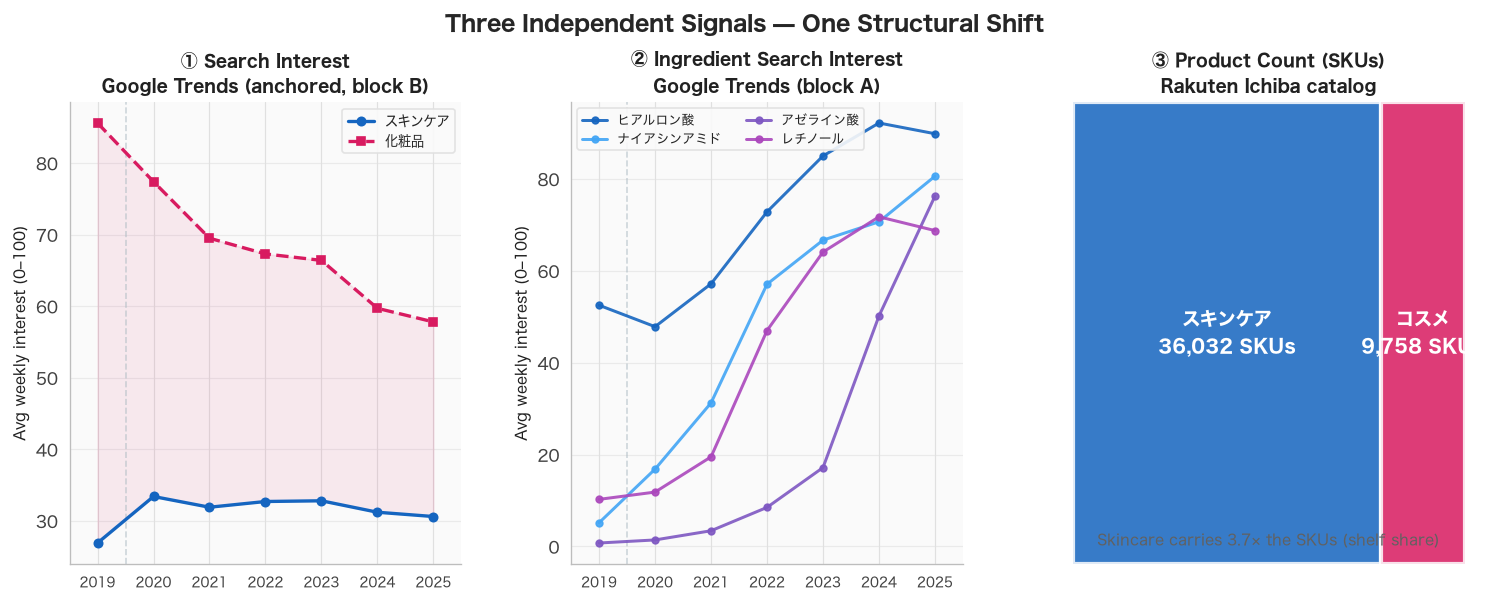

Saved: outputs/nb05_small_multiples.png


In [11]:
# ── Reopen connection (safety) ────────────────────────────────────────────
from src.schema import get_connection
conn = get_connection()

import matplotlib.gridspec as gridspec
import squarify

# ── Ingredient annual averages ───────────────────────────────────────────
ingredient_terms_safe = ','.join(f"'{t}'" for t in ingredient_terms)
sql_ing_annual = f"""
    SELECT CAST(SUBSTR(week_start,1,4) AS INT) AS yr,
           term, AVG(interest) AS avg_int
    FROM trends_weekly
    WHERE term_group='block_A'
      AND term IN ({ingredient_terms_safe})
    GROUP BY yr, term HAVING yr BETWEEN 2019 AND 2025
"""
df_ing_annual = pd.read_sql(sql_ing_annual, conn)
top_terms_plot = df_ing_sum.sort_values(
    'avg_post_covid', ascending=False).head(4)['term'].tolist()

# ── Three independent signals (review volume excluded — see §1) ──────────
fig = plt.figure(figsize=(15, 5), facecolor='white')
fig.suptitle('Three Independent Signals — One Structural Shift',
             fontsize=13, fontweight='bold', y=1.03)

gs = gridspec.GridSpec(1, 3, wspace=0.28)
ax1, ax2, ax3 = [fig.add_subplot(gs[0, c]) for c in range(3)]
years = list(range(2019, 2026))

for ax in (ax1, ax2):
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#BDBDBD')
    ax.spines['bottom'].set_color('#BDBDBD')
    ax.grid(axis='y', color='#E0E0E0', linewidth=0.7, alpha=0.6)
    ax.axvline(2019.5, color='#B0BEC5', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_xlim(2018.5, 2025.5)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], fontsize=8)

# Panel 1 — search interest (anchored block B)
if len(df_trends) > 0:
    skin_t = df_trends[df_trends.signal_class == 'skincare_signal'].set_index('trend_year')
    cosm_t = df_trends[df_trends.signal_class == 'cosmetics_signal'].set_index('trend_year')
    sx = [y for y in years if y in skin_t.index]
    cx = [y for y in years if y in cosm_t.index]
    ax1.plot(sx, [skin_t.loc[y, 'avg_interest'] for y in sx],
             'o-', color=C_SKIN, linewidth=2, markersize=5, label='スキンケア')
    ax1.plot(cx, [cosm_t.loc[y, 'avg_interest'] for y in cx],
             's--', color=C_COSM, linewidth=2, markersize=5, label='化粧品')
    common = [y for y in years if y in skin_t.index and y in cosm_t.index]
    ax1.fill_between(common,
                     [skin_t.loc[y, 'avg_interest'] for y in common],
                     [cosm_t.loc[y, 'avg_interest'] for y in common],
                     alpha=0.08, color=C_COSM)
ax1.set_title('① Search Interest\nGoogle Trends (anchored, block B)',
              fontsize=10, fontweight='bold')
ax1.set_ylabel('Avg weekly interest (0–100)', fontsize=9)
ax1.legend(fontsize=8, loc='upper right')

# Panel 2 — ingredient search
colors2 = [C_SKIN, '#42A5F5', '#7E57C2', '#AB47BC']
for term, color in zip(top_terms_plot, colors2):
    grp = df_ing_annual[df_ing_annual.term == term].set_index('yr')
    gx = [y for y in years if y in grp.index]
    ax2.plot(gx, [grp.loc[y, 'avg_int'] for y in gx],
             'o-', color=color, linewidth=1.8, markersize=4, label=term, alpha=0.9)
ax2.set_title('② Ingredient Search Interest\nGoogle Trends (block A)',
              fontsize=10, fontweight='bold')
ax2.set_ylabel('Avg weekly interest (0–100)', fontsize=9)
ax2.legend(fontsize=7.5, loc='upper left', ncol=2)

# Panel 3 — Rakuten SKU treemap
if len(df_rak_tier) > 0:
    rak_data = df_rak_tier.set_index('tier')
    skin_n = rak_data.loc['skincare', 'product_count'] if 'skincare' in rak_data.index else 0
    cosm_n = rak_data.loc['cosmetics', 'product_count'] if 'cosmetics' in rak_data.index else 0
    ratio = skin_n / max(cosm_n, 1)
    squarify.plot(sizes=[skin_n, cosm_n],
                  label=[f'スキンケア\n{skin_n:,} SKUs', f'コスメ\n{cosm_n:,} SKUs'],
                  color=[C_SKIN, C_COSM], alpha=0.85, ax=ax3,
                  text_kwargs={'fontsize': 11, 'fontweight': 'bold', 'color': 'white'},
                  bar_kwargs={'edgecolor': 'white', 'linewidth': 2.5})
    ax3.text(0.5, 0.04, f'Skincare carries {ratio:.1f}× the SKUs (shelf share)',
             transform=ax3.transAxes, ha='center', fontsize=9,
             color='#616161', style='italic')
ax3.set_title('③ Product Count (SKUs)\nRakuten Ichiba catalog',
              fontsize=10, fontweight='bold')
ax3.set_xlim(0, 100); ax3.set_ylim(0, 100)
ax3.set_xticks([]); ax3.set_yticks([])
for s in ('left', 'bottom', 'top', 'right'):
    ax3.spines[s].set_visible(False)

tight(fig, '../outputs/nb05_small_multiples.png')
plt.show()
print('Saved: outputs/nb05_small_multiples.png')

Saved → ../outputs/nb05_slope_chart.png


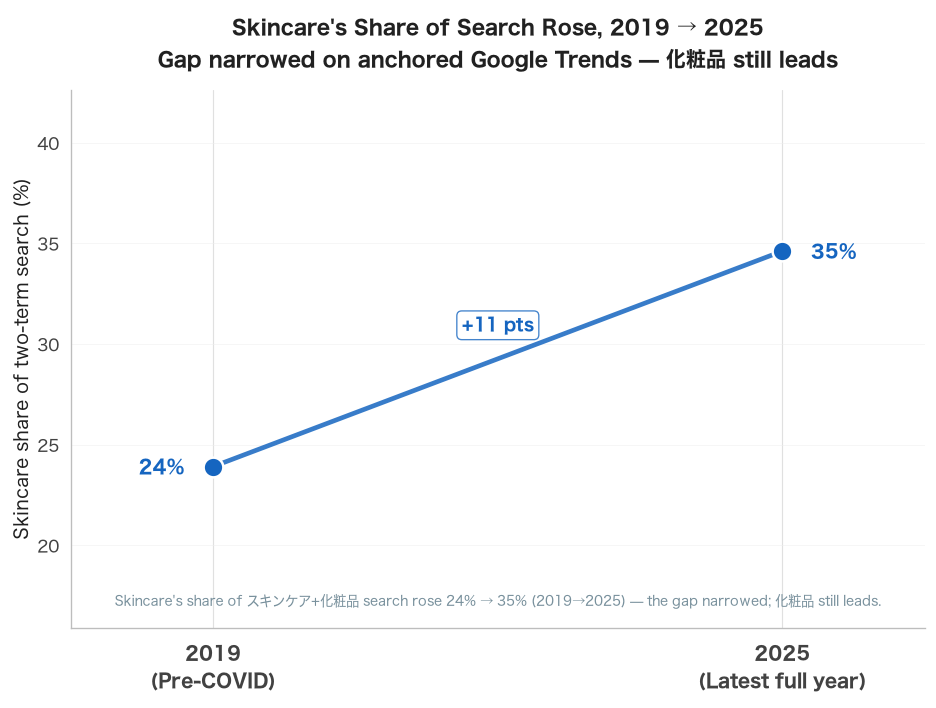

Saved: outputs/nb05_slope_chart.png


In [12]:
# Slope chart — skincare's share of スキンケア+化粧品 search, 2019 → 2025.
# Single signal: search-interest share (anchored block B). Review share and the
# Rakuten static snapshot are excluded — neither belongs on a before/after axis.
# y-axis starts above zero: legitimate for a slope chart, where the point is change.

def search_share(year):
    s = df_trends[(df_trends.signal_class == 'skincare_signal') &
                  (df_trends.trend_year == year)]['avg_interest'].values
    c = df_trends[(df_trends.signal_class == 'cosmetics_signal') &
                  (df_trends.trend_year == year)]['avg_interest'].values
    if len(s) and len(c) and (s[0] + c[0]) > 0:
        return 100 * s[0] / (s[0] + c[0])
    return None

ss19, ss25 = search_share(2019), search_share(2025)

fig, ax = fig_ax(8, 6)
ax.set_facecolor('white')
ax.grid(axis='y', color='#EEEEEE', linewidth=0.6, alpha=0.5)

if ss19 is not None and ss25 is not None:
    delta = ss25 - ss19
    ax.plot([0, 1], [ss19, ss25], '-', color=C_SKIN, linewidth=2.8, alpha=0.85, zorder=2)
    ax.scatter([0, 1], [ss19, ss25], s=140, color=C_SKIN, zorder=4,
               edgecolors='white', linewidths=1.5)
    ax.text(-0.05, ss19, f'{ss19:.0f}%', ha='right', va='center',
            fontsize=11, color=C_SKIN, fontweight='bold')
    ax.text(1.05, ss25, f'{ss25:.0f}%', ha='left', va='center',
            fontsize=11, color=C_SKIN, fontweight='bold')
    ax.text(0.5, (ss19 + ss25) / 2 + 1.2, f'+{delta:.0f} pts',
            ha='center', va='bottom', fontsize=10, color=C_SKIN, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=C_SKIN, alpha=0.8, linewidth=0.8))
    ax.text(0.5, 0.03,
            f'Skincare\'s share of スキンケア+化粧品 search rose {ss19:.0f}% → {ss25:.0f}% '
            f'(2019→2025) — the gap narrowed; 化粧品 still leads.',
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=8, color='#78909C', style='italic', linespacing=1.5)
    pad = 8
    ax.set_ylim(min(ss19, ss25) - pad, max(ss19, ss25) + pad)

ax.set_xlim(-0.25, 1.25)
ax.set_xticks([0, 1])
ax.set_xticklabels(['2019\n(Pre-COVID)', '2025\n(Latest full year)'],
                   fontsize=11, fontweight='bold')
ax.set_ylabel('Skincare share of two-term search (%)', fontsize=11)
ax.set_title("Skincare's Share of Search Rose, 2019 → 2025\n"
             "Gap narrowed on anchored Google Trends — 化粧品 still leads",
             fontsize=12, fontweight='bold', pad=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#BDBDBD')
ax.spines['bottom'].set_color('#BDBDBD')

tight(fig, '../outputs/nb05_slope_chart.png')
plt.show()
print('Saved: outputs/nb05_slope_chart.png')


In [13]:
from IPython.display import display, Markdown

# ── Recompute summary values (safe to re-run) ─────────────────────────────
if len(df_trends) > 0:
    import datetime as _dt
    skin_by_yr = df_trends[df_trends.signal_class == "skincare_signal"].set_index("trend_year")["avg_interest"]
    cosm_by_yr = df_trends[df_trends.signal_class == "cosmetics_signal"].set_index("trend_year")["avg_interest"]
    _first = int(cosm_by_yr.index.min()); _last = int(cosm_by_yr.index.max())
    if _last == _dt.date.today().year:   # drop a partial current year
        _last -= 1
    _decl = 100 * (cosm_by_yr[_last] - cosm_by_yr[_first]) / cosm_by_yr[_first]
    _r0 = skin_by_yr[_first] / cosm_by_yr[_first]
    _r1 = skin_by_yr[_last] / cosm_by_yr[_last]
    trends_str = (f"化粧品 {_decl:+.0f}% ({_first}→{_last}), スキンケア roughly flat — "
                  f"**no crossover**; the スキンケア:化粧品 ratio rises {_r0:.2f}→{_r1:.2f} "
                  f"while 化粧品 leads every year")
else:
    trends_str = "See §3"

if len(df_ing_sum) > 0:
    _d = df_ing_sum.assign(delta=df_ing_sum["avg_post_covid"] - df_ing_sum["avg_pre_covid"])
    _n = df_ing_sum[df_ing_sum["term"] == "ナイアシンアミド"]
    _nia0 = float(_n["avg_pre_covid"].iloc[0]) if len(_n) else 0.0
    _nia1 = float(_n["avg_post_covid"].iloc[0]) if len(_n) else 0.0
    top = _d.sort_values("delta", ascending=False).iloc[0]
    ing_str = f"**{top['term']}** {top['avg_pre_covid']:.0f} → {top['avg_post_covid']:.0f} (+{top['delta']:.0f}, {Y0} vs {Y1})"
else:
    ing_str = "See §4"
    _nia0 = _nia1 = 0.0

if len(df_rak_tier) > 0:
    rs = df_rak_tier[df_rak_tier.tier == "skincare"]["product_count"].values
    rc = df_rak_tier[df_rak_tier.tier == "cosmetics"]["product_count"].values
    rak_ratio = f"{rs[0]:,} vs {rc[0]:,} ({rs[0]/max(rc[0],1):.1f}× ratio)" if len(rs) and len(rc) else "N/A"
else:
    rak_ratio = "N/A"

display(Markdown(f"""
## NB05 — The Shift: Findings

Partially confirmed: the direction holds across independent signals, the magnitude
is moderate, and review *volume* is excluded as a scraping-coverage artifact (§1–2).

---

### 1. Search demand — Google Trends (anchored, block B)

{trends_str}. The cyclical rival explanation — a mask effect — is tested directly
in the dashboard mask panel and rejected: makeup search did not recover after masks
came off.

### 2. Ingredient search — Google Trends (block A)

{ing_str}. Near-zero to prominent: retinol, niacinamide, azelaic acid — consumers
searching actives by name.

### 3. Commercial supply — Rakuten Ichiba

**{rak_ratio}** — shelf share, not sales. SKU count also reflects catalogue scope,
so it corroborates the demand signal rather than measuring demand.

### Excluded — @cosme review volume (§1–2)

Tier share of review volume tracks scraping coverage, not the market, and is not
used as a shift metric. @cosme's contribution is *language*, analysed in NB06.

---

### Verdict: partially confirmed — direction clear, magnitude moderate

化粧品 search falls ~a third while スキンケア holds flat; the gap narrows but does
not cross; ingredient search rises (niacinamide {_nia0:.0f}→{_nia1:.0f}, {Y0} vs {Y1});
Rakuten shelf share runs ~3.7× skincare. A real shift, not a dramatic one.

**→ NB06:** the discovery layer — *what* changed in the language, and which brands
lead the fastest-rising searches.
"""))



## NB05 — The Shift: Findings

Partially confirmed: the direction holds across independent signals, the magnitude
is moderate, and review *volume* is excluded as a scraping-coverage artifact (§1–2).

---

### 1. Search demand — Google Trends (anchored, block B)

化粧品 -32% (2019→2025), スキンケア roughly flat — **no crossover**; the スキンケア:化粧品 ratio rises 0.31→0.53 while 化粧品 leads every year. The cyclical rival explanation — a mask effect — is tested directly
in the dashboard mask panel and rejected: makeup search did not recover after masks
came off.

### 2. Ingredient search — Google Trends (block A)

**アゼライン酸** 1 → 76 (+76, 2019 vs 2025). Near-zero to prominent: retinol, niacinamide, azelaic acid — consumers
searching actives by name.

### 3. Commercial supply — Rakuten Ichiba

**36,032 vs 9,758 (3.7× ratio)** — shelf share, not sales. SKU count also reflects catalogue scope,
so it corroborates the demand signal rather than measuring demand.

### Excluded — @cosme review volume (§1–2)

Tier share of review volume tracks scraping coverage, not the market, and is not
used as a shift metric. @cosme's contribution is *language*, analysed in NB06.

---

### Verdict: partially confirmed — direction clear, magnitude moderate

化粧品 search falls ~a third while スキンケア holds flat; the gap narrows but does
not cross; ingredient search rises (niacinamide 5→81, 2019 vs 2025);
Rakuten shelf share runs ~3.7× skincare. A real shift, not a dramatic one.

**→ NB06:** the discovery layer — *what* changed in the language, and which brands
lead the fastest-rising searches.


In [14]:
conn.close()
print()
print('=' * 60)
print('NB05 — The Shift: Confirmatory Analysis: COMPLETE')
print('=' * 60)
print('Proceed to NB05a/b — Company lens notebooks (private, gitignored)')



NB05 — The Shift: Confirmatory Analysis: COMPLETE
Proceed to NB05a/b — Company lens notebooks (private, gitignored)
